# FPM SIMULATION


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

##### Defining Parameters

In [10]:
# Illumination & Setup
wavelength = 532e-9        # LED wavelength (m)
array_size = 7              # 7x7 LED array
led_pitch = 4e-3           # 4mm spacing between LEDs
z_led = 60e-3              # 60mm distance from LED to sample

# Objective Lens & Camera
NA = 0.08                   # Objective Numerical Aperture
mag = 2.0                  # Magnification
pixel_size = 6.5e-6        # Typical sCMOS camera pixel size (m)
pixel_size_eff = pixel_size / mag      # Effective pixel size at the object plane (3.25 um)

# Grid Sizes (Powers of 2 for efficient FFT)
N_LR = 64                  # Low-Res image dimensions (64x64)
ds = 4                     # Upsampling factor for High-Res reconstruction
N_HR = N_LR * ds           # High-Res object dimensions (256x256)
pixel_size_HR = pixel_size_eff / ds     # High-Res pixel size (0.8125 um)

##### GROUND TRUTH OBJECT

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

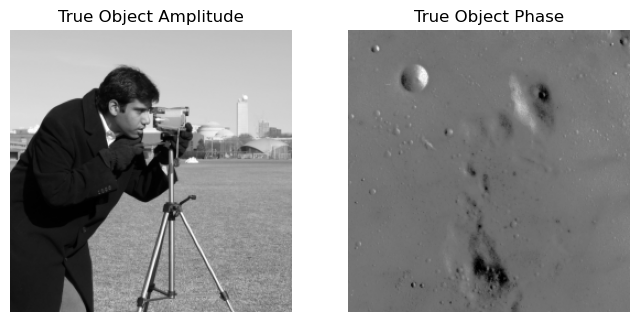

In [11]:
# Amplitude: Cameraman, Phase: Moon
amp = transform.resize(data.camera(), (N_HR, N_HR), anti_aliasing=True) 
#anti_aliasing=True applies a Gaussian smoothing filter before resampling, which helps produce smoother results.
amp = amp / amp.max()                                #Normalization

phase = transform.resize(data.moon(), (N_HR, N_HR), anti_aliasing=True)
phase = (phase / phase.max()) * np.pi - (np.pi/2)    # Scale phase between -pi/2 and pi/2

obj_true = amp * np.exp(1j * phase)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    
axs[0].imshow(np.abs(obj_true), cmap='gray')
axs[0].set_title('True Object Amplitude')
axs[0].axis('off')

axs[1].imshow(np.angle(obj_true), cmap='gray')
axs[1].set_title('True Object Phase')
axs[1].axis('off')

##### PUPIL FUNCTION (Low-Pass Filter)

Cutoff frequency =  150375.93984962406


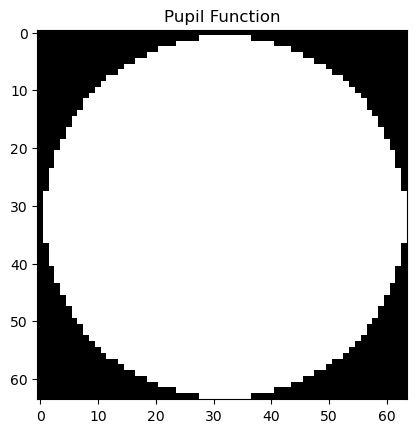

In [12]:
# The pupil acts as a low-pass filter in the Fourier domain
# np.fft.fftfreq(n, d); n = number of samples, d = sample spacing
fx_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=pixel_size_eff))
fy_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=pixel_size_eff))
FX_LR, FY_LR = np.meshgrid(fx_LR, fy_LR)

cutoff_freq = NA / wavelength
print('Cutoff frequency = ',cutoff_freq)
pupil = (FX_LR**2 + FY_LR**2 <= cutoff_freq**2).astype(float)

plt.figure()
plt.imshow(pupil, cmap='gray')
plt.title('Pupil Function')
plt.show()

##### LED array Visualization

Text(0, 0.5, 'Positions of LED (in metres)')

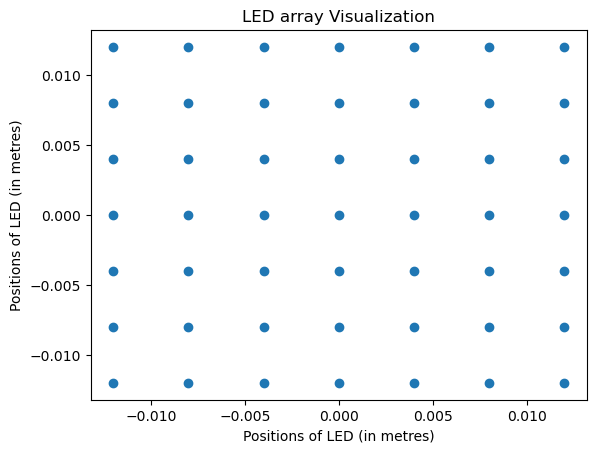

In [19]:
# Calculate LED positions
led_idx = np.arange(array_size) - (array_size)// 2
x_led, y_led = np.meshgrid(led_idx * led_pitch, led_idx * led_pitch)

plt.scatter(x_led,y_led)
plt.title('LED array Visualization')
plt.xlabel('Positions of LED (in metres)')
plt.ylabel('Positions of LED (in metres)')

##### FORWARD MODEL (Simulating LR Captures)

In [ ]:
# High-Res frequency space coordinates
df_HR = 1.0 / (N_HR * pixel_size_HR)

# Illumination angles and k-vector shifts
sin_theta_x = x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
sin_theta_y = y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)

kx_led = -sin_theta_x / wavelength
ky_led = -sin_theta_y / wavelength

# Generate HR Object Spectrum
O_HR = np.fft.fftshift(np.fft.fft2(obj_true))

# Store captured Low-Res intensity images
I_measure = np.zeros((array_size, array_size, N_LR, N_LR))